<a href="https://colab.research.google.com/github/alifnw/3-Alif-Livyandra/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maternal Health Risk Classification
## Weekly Report 2 — Data Overview, Visualization & Pre-Processing

#Import Library

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# !pip install pandas numpy matplotlib plotly seaborn missingno

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import missingno as msno

#Load Data

In [4]:
filepath = 'https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/main/data/raw/Dataset%20-%20Updated.csv'
df = pd.read_csv(filepath)

# Data Understanding

###Background

Komplikasi kehamilan menjadi salah satu penyebab utama kematian ibu
di negara berkembang. Identifikasi dini terhadap pasien berisiko tinggi
sangat krusial, namun proses penilaian yang masih dilakukan secara manual
rentan terhadap keterlambatan penanganan. Proyek ini memanfaatkan data
klinis ibu hamil untuk membangun model klasifikasi berbasis machine learning
yang mampu mendeteksi risiko komplikasi secara otomatis, sehingga tenaga
medis dapat mengambil keputusan klinis lebih cepat dan berbasis data.

###Tujuan EDA

1. **Memahami Data** — Mengetahui karakteristik dasar setiap fitur
2. **Identifikasi Anomali** — Menemukan missing values, duplikat, dan outlier
3. **Identifikasi Pola dan Tren** — Melihat distribusi dan persebaran data
4. **Eksplorasi Hubungan** — Memahami hubungan antar fitur dan terhadap target

Analisis yang dilakukan meliputi:
- Measure of Central Tendency: mean, median, modus
- Measure of Spread: variabilitas, varian, standar deviasi
- Measure of Distribution: skewness dan kurtosis

###Tentang Dataset

Dataset ini merupakan data rekam medis nyata yang dikumpulkan dari
**Kurigram General Hospital, Bangladesh**, mencakup data ibu hamil
yang menjalani pemeriksaan klinis rutin. Dataset dipublikasikan melalui
jurnal ilmiah ScienceDirect (Februari 2025) sehingga kredibilitasnya
dapat dipertanggungjawabkan secara akademis.

###Dataset Glosary

| Kolom | Tipe | Deskripsi |
|---|---|---|
| **Age** | Numerik | Usia ibu hamil dalam satuan tahun |
| **Systolic BP** | Numerik | Tekanan darah sistolik (mmHg) — tekanan saat jantung memompa |
| **Diastolic** | Numerik | Tekanan darah diastolik (mmHg) — tekanan saat jantung beristirahat |
| **BS** | Numerik | Kadar gula darah (mmol/L) — indikator diabetes gestasional |
| **Body Temp** | Numerik | Suhu tubuh ibu (°F) — indikator infeksi atau demam |
| **BMI** | Numerik | Indeks Massa Tubuh — indikator status gizi |
| **Heart Rate** | Numerik | Detak jantung (bpm) — indikator kondisi kardiovaskular |
| **Previous Complications** | Biner (0/1) | Riwayat komplikasi pada kehamilan sebelumnya |
| **Preexisting Diabetes** | Biner (0/1) | Diabetes yang sudah ada sebelum kehamilan |
| **Gestational Diabetes** | Biner (0/1) | Diabetes yang timbul selama masa kehamilan |
| **Mental Health** | Biner (0/1) | Gangguan kesehatan mental selama kehamilan |
| **Risk Level** | Target | Tingkat risiko kehamilan: **High** atau **Low** |

### SMART Analysis



| | Pertanyaan | Jawaban |
|---|---|---|
| **Specific** | Apa tujuan project ini? | Membangun model klasifikasi untuk mendeteksi risiko kehamilan berdasarkan data klinis ibu hamil |
| **Measurable** | Bagaimana mengukur keberhasilan? | Melalui metrik evaluasi model: accuracy, precision, recall, dan F1-score |
| **Action Oriented** | Apa langkah yang dilakukan? | EDA → Preprocessing → Feature Engineering → Modeling → Evaluasi |
| **Relevant** | Seberapa relevan topik ini? | Deteksi dini risiko kehamilan dapat membantu tenaga medis memprioritaskan penanganan pasien yang paling membutuhkan |
| **Time-Bound** | Kapan batas waktunya? | Project ini ditargetkan selesai dan dipresentasikan pada final pitching **4 April 2026**  |

### Business Questions

1. Faktor klinis apa yang paling membedakan pasien High Risk dan Low Risk?
2. Apakah riwayat kondisi medis sebelumnya berpengaruh terhadap
   tingkat risiko kehamilan?
3. Seperti apa karakteristik data klinis pasien berdasarkan tingkat risikonya?

#Data Overview

###Basic Information

In [5]:
df.shape

(1205, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   str    
dtypes: float64(7), int64(4), str(1)
memory usage: 113.1 KB


In [7]:
df.describe()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


In [8]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [9]:
df.tail()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
1200,41,140.0,95.0,16.0,98,22.0,0.0,0.0,1,1,90.0,High
1201,25,110.0,90.0,6.0,98,19.0,0.0,0.0,1,1,92.0,High
1202,21,150.0,110.0,4.9,98,21.5,0.0,0.0,1,1,66.0,High
1203,23,130.0,100.0,5.1,98,27.0,0.0,0.0,1,1,60.0,High
1204,26,120.0,90.0,6.7,98,23.9,0.0,0.0,1,0,58.0,High


In [10]:
df.sample(5)

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
982,34,170.0,90.0,8.8,98,37.0,1.0,0.0,1,1,88.0,High
1015,27,90.0,65.0,7.0,101,26.6,1.0,0.0,1,1,88.0,High
216,33,100.0,60.0,7.0,98,20.0,0.0,0.0,0,0,72.0,Low
801,60,90.0,65.0,7.0,98,23.4,0.0,0.0,0,0,77.0,Low
321,39,110.0,70.0,7.0,98,22.0,0.0,0.0,0,0,70.0,Low


###Missing Value

In [11]:
df.isnull().sum()

Age                        0
Systolic BP                5
Diastolic                  4
BS                         2
Body Temp                  0
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Gestational Diabetes       0
Mental Health              0
Heart Rate                 2
Risk Level                18
dtype: int64

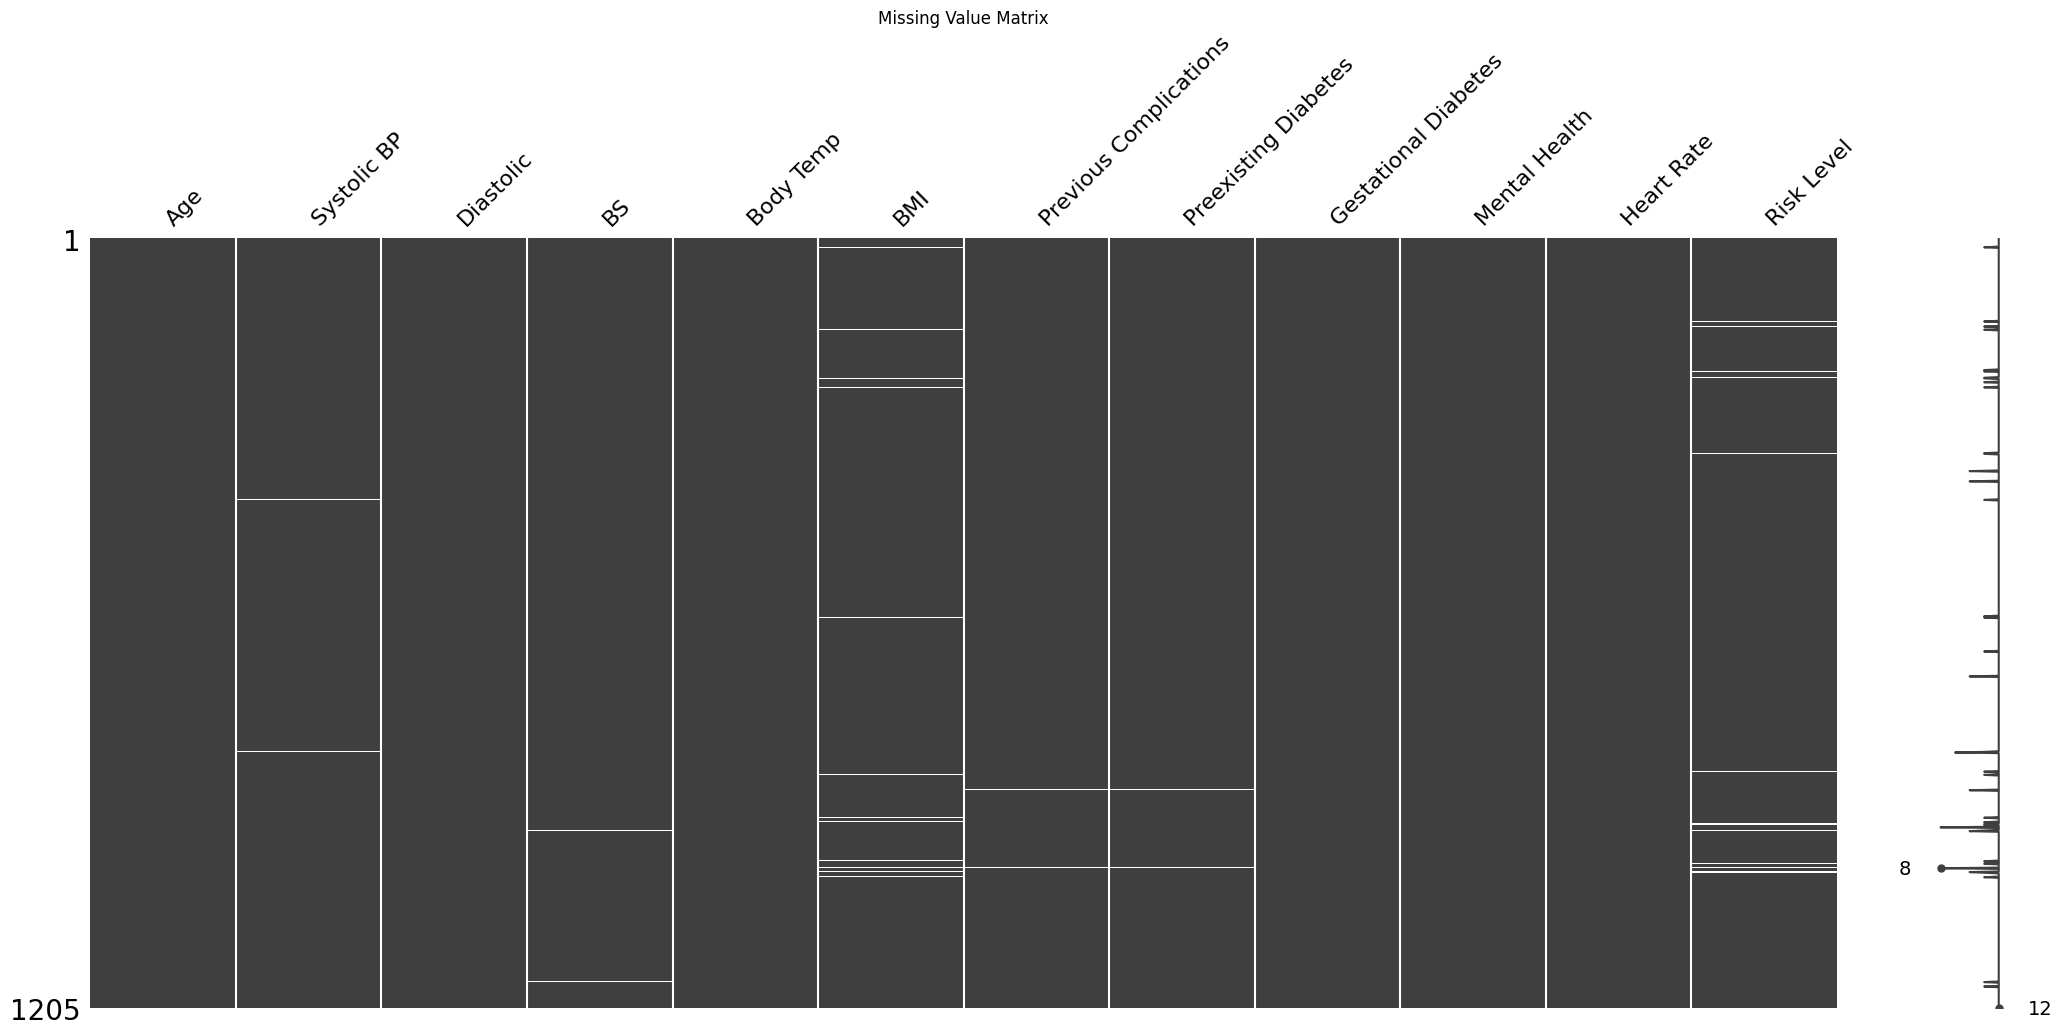

In [12]:
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

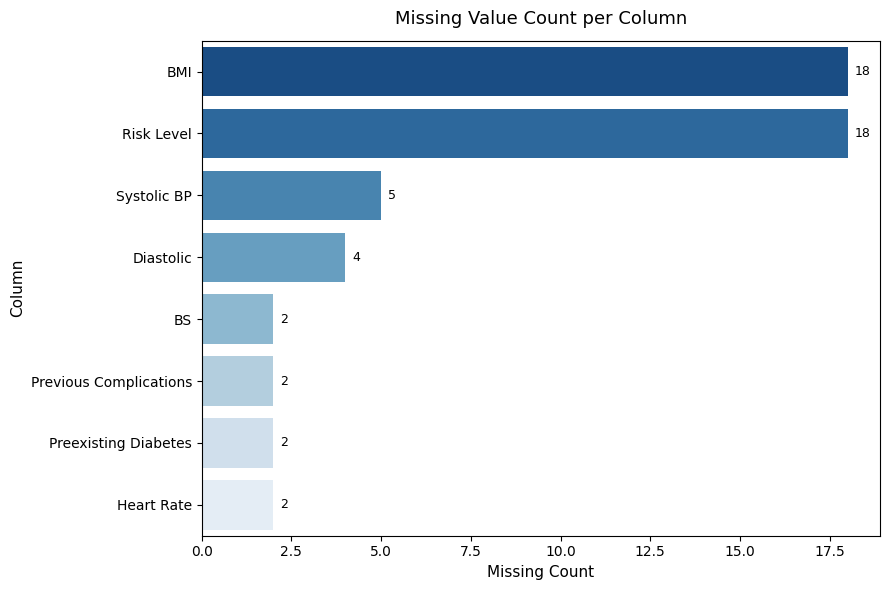

In [13]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=missing_counts.values, y=missing_counts.index,
                 hue=missing_counts.index,
                 palette="Blues_r", legend=False)


for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left", va="center", fontsize=9, xytext=(5, 0), textcoords='offset points')

plt.title("Missing Value Count per Column", fontsize=13, pad=12)
plt.xlabel("Missing Count", fontsize=11)
plt.ylabel("Column", fontsize=11)
plt.tight_layout()
plt.show()

### Duplicated Values

Non-Duplikat : 1187 (98.5%)
Duplikat     : 18 (1.5%)
Total        : 1205


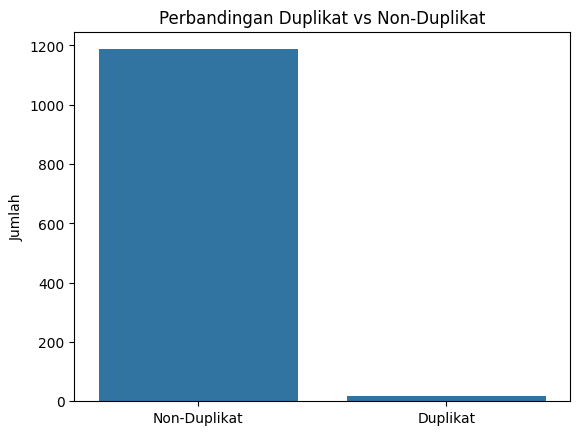

In [14]:
total = len(df)
duplikat = df.duplicated().sum()
non_duplikat = total - duplikat

print(f"Non-Duplikat : {non_duplikat} ({non_duplikat/total*100:.1f}%)")
print(f"Duplikat     : {duplikat} ({duplikat/total*100:.1f}%)")
print(f"Total        : {total}")

sns.barplot(x=['Non-Duplikat', 'Duplikat'],
            y=[non_duplikat, duplikat])
plt.title('Perbandingan Duplikat vs Non-Duplikat')
plt.ylabel('Jumlah')
plt.show()

### Distribusi Kasar

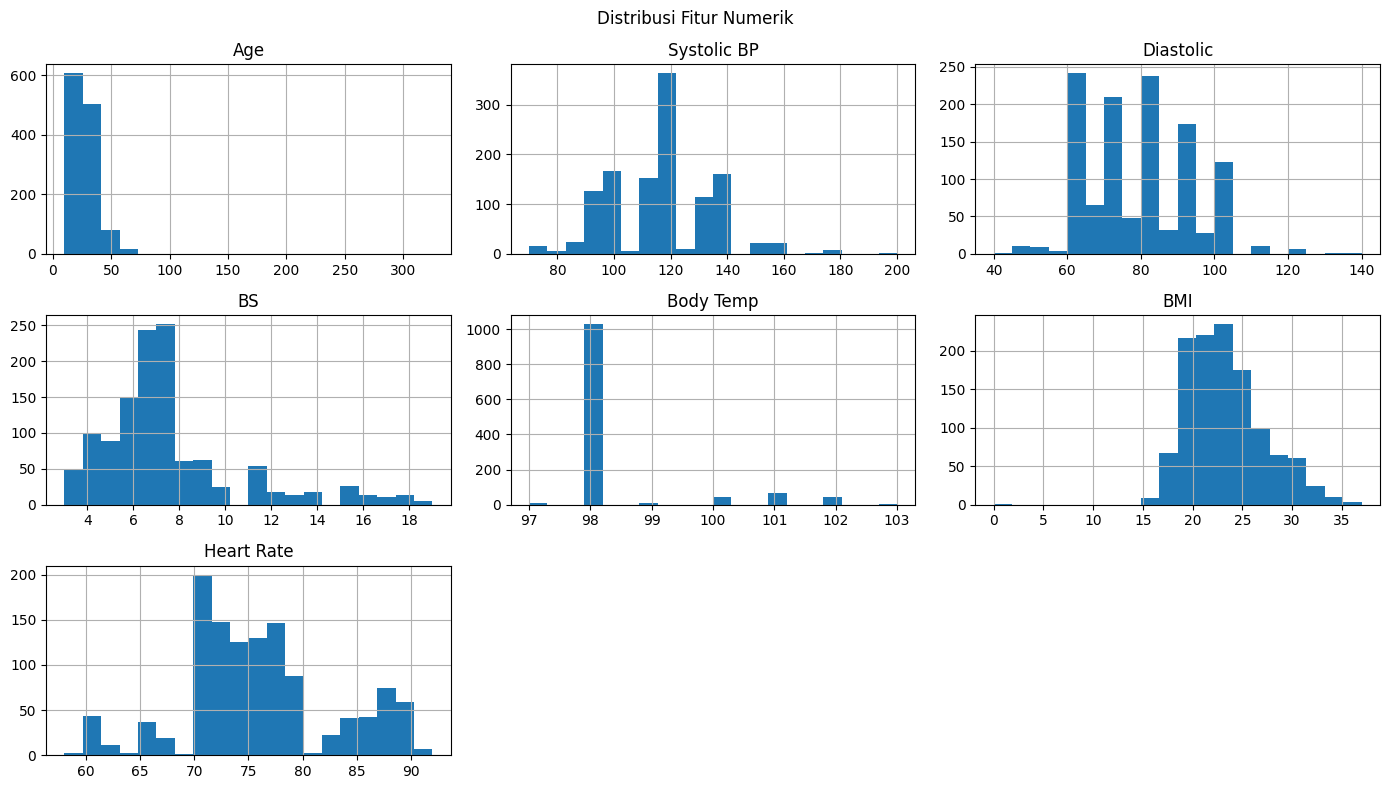

In [15]:
num_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']

df[num_cols].hist(figsize=(14, 8), bins=20)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

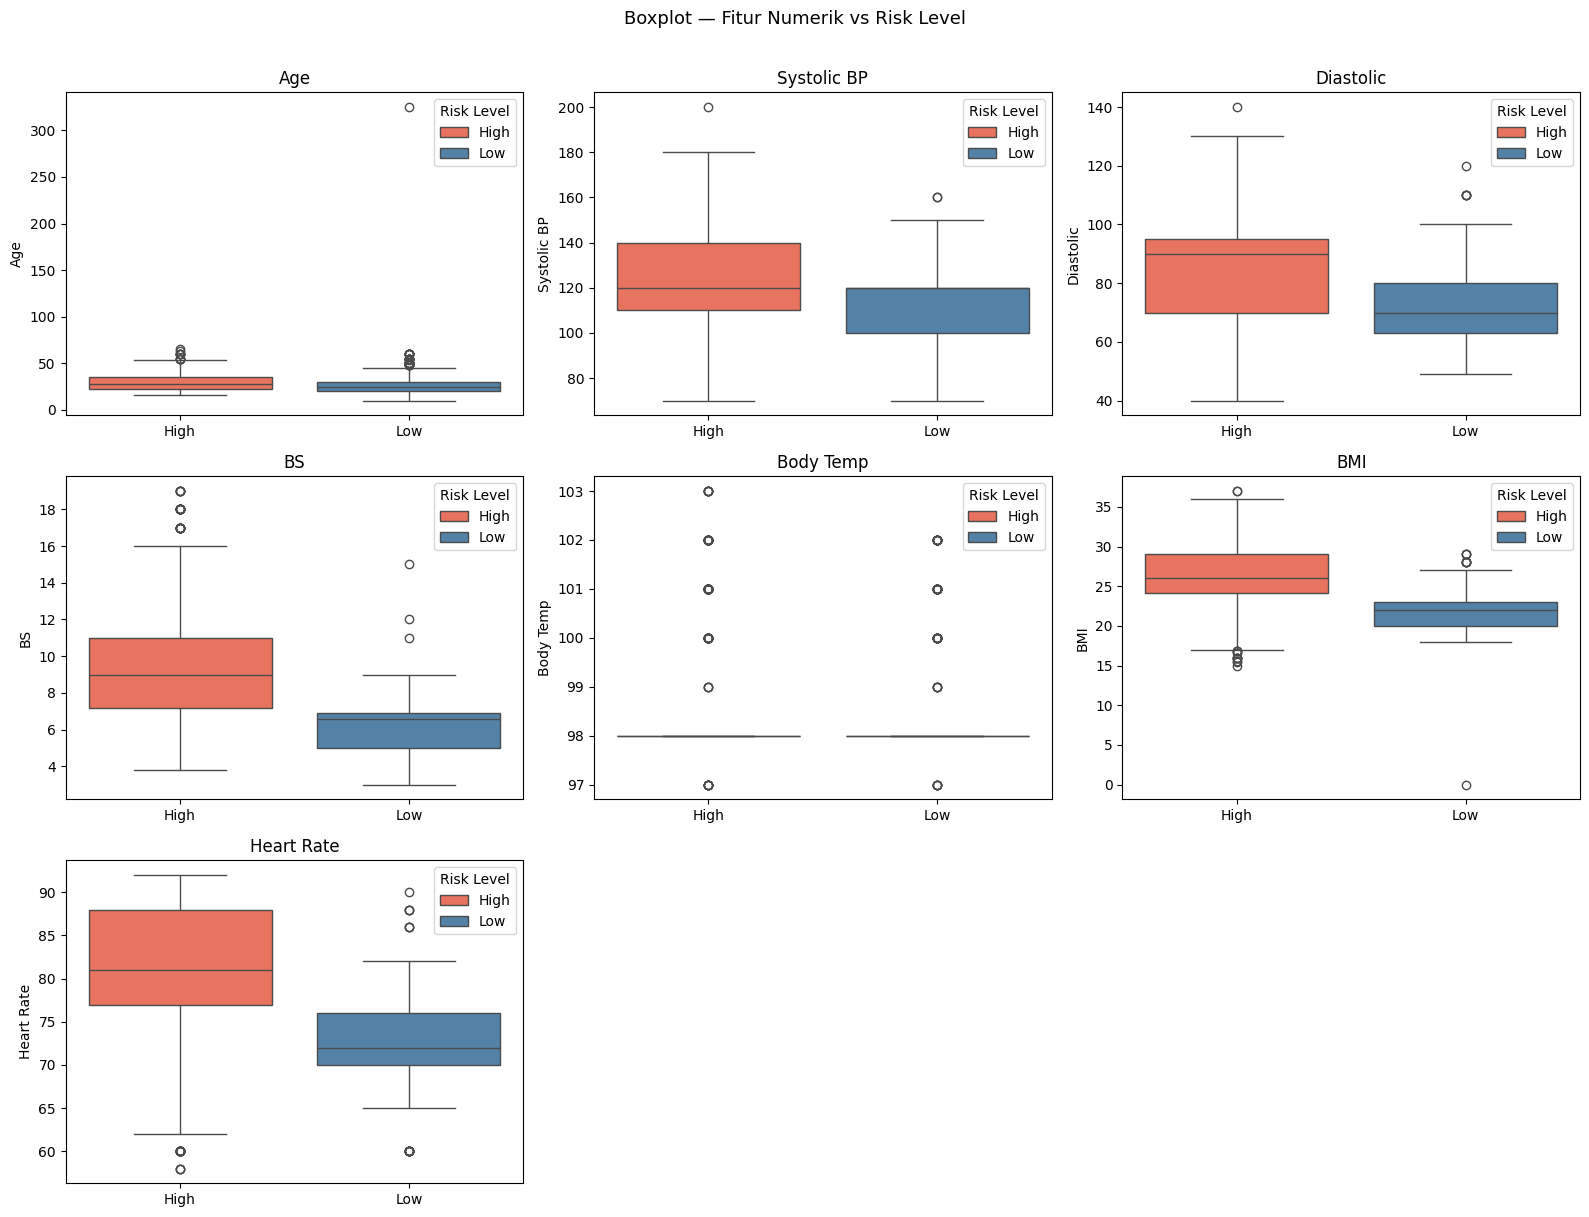

In [16]:
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Risk Level", y=col, ax=axes[i],
                order=["High", "Low"],
                hue = "Risk Level",
                palette={"High": "tomato", "Low": "steelblue"})
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot — Fitur Numerik vs Risk Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

###Insight yang bisa kita ambil dari Data Overview

- Ditemukan **18 baris duplikat** (1.5%) yang perlu di-drop
- Terdapat missing values pada beberapa kolom, terbanyak di **BMI (18 baris)**
  dan **Risk Level (18 baris)**
- Ditemukan anomali **Age = 325** yang tidak mungkin secara medis —
  diduga data entry error
- Ditemukan anomali **BMI = 0** yang tidak valid secara fisik —
  diduga data entry error
- Missing value pada **Systolic BP dan Diastolic cenderung terjadi bersamaan**
  (korelasi 0.7), begitu juga **Previous Complications dan Preexisting Diabetes**
  (korelasi 1.0)
- Dataset memiliki mild imbalance: **High Risk 39.3%** vs **Low Risk 59.2%**

#Data Cleaning

### Drop Duplikat

In [17]:
df_clean = df.copy()

print(f"Original shape         : {df.shape}")

df_clean = df_clean.drop_duplicates()
print(f"After drop duplicates  : {df_clean.shape}")


Original shape         : (1205, 12)
After drop duplicates  : (1187, 12)


### Drop Missing Value Target (Tidak bisa diimputasi)

In [18]:
df_clean = df_clean.dropna(subset=["Risk Level"])
print(f"After drop null target : {df_clean.shape}")

After drop null target : (1169, 12)


### Imputasi Missing Values

In [19]:

num_cols = df_clean.select_dtypes(include=["number"]).columns
cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Imputed (median) : {col} = {median_val}")

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Imputed (mode)   : {col} = {mode_val}")

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Imputed (median) : Systolic BP = 120.0
Imputed (median) : Diastolic = 80.0
Imputed (median) : BS = 6.9
Imputed (median) : BMI = 23.0
Imputed (median) : Previous Complications = 0.0
Imputed (median) : Preexisting Diabetes = 0.0
Imputed (median) : Heart Rate = 76.0
Missing values remaining: 0


C:\Users\USER\AppData\Local\Temp\ipykernel_17248\1108843860.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=["object", "category", "bool"]).columns


### Domain-Based Capping

In [20]:
# ── Domain-Based Capping (Clinical Threshold Winsorization) ──
# Each bound is backed by peer-reviewed clinical guidelines.
#
# REFERENCES:
# [1] WHO. Diagnostic Criteria and Classification of Hyperglycaemia
#     First Detected in Pregnancy. Geneva: WHO; 2013.
#     https://www.ncbi.nlm.nih.gov/books/NBK169023/
#
# [2] ACOG Practice Bulletin No. 222: Gestational Hypertension and
#     Preeclampsia. Obstet Gynecol. 2020;135(6):e237-e260.
#     https://doi.org/10.1097/AOG.0000000000003891
#
# [3] ACOG Committee Opinion No. 692: Emergent Therapy for
#     Acute-Onset, Severe Hypertension During Pregnancy and the
#     Postpartum Period. Obstet Gynecol. 2017;129:e90-e95.
#
# [4] ACOG Obstetric Care Consensus No. 11: Pregnancy at Age 35
#     Years or Older. Obstet Gynecol. 2022;140(2):348-366.
#     https://doi.org/10.1097/AOG.0000000000004906
#
# [5] WHO. BMI Classification. Global Database on Body Mass Index.
#     World Health Organization; 2004.
#
# [6] Monga M. Maternal cardiovascular and renal adaptation to
#     pregnancy. In: Creasy RK, Resnik R, eds. Maternal-Fetal
#     Medicine. 5th ed. Saunders; 2004.

clinical_bounds = {
    #  Age: lower = menarche biological minimum (ACOG OCC No. 11);
    #       upper = extreme upper boundary, natural conception after
    #       45 is unlikely; 50 used as clinical hard ceiling [4]
    "Age":         (12, 50),

    #  Systolic BP: lower = hypotensive threshold indicating
    #               hypovolemic shock (MAP collapse);
    #               upper = severe-range preeclampsia threshold
    #               per ACOG PB 222, treatment mandated at >=160;
    #               220 represents hypertensive crisis ceiling [2][3]
    "Systolic BP": (70, 220),

    #  Diastolic: lower = vascular collapse threshold;
    #             upper = severe preeclampsia per ACOG PB 222
    #             defined as DBP >= 110; 130 represents
    #             hypertensive emergency ceiling [2][3]
    "Diastolic":   (40, 130),

    #  BS (Blood Sugar, mmol/L):
    #     lower = ADA Level 2 severe hypoglycemia threshold (<3.0)
    #             requiring immediate intervention;
    #     upper = DKA-range hyperglycemia. WHO 2013 criteria define
    #             overt diabetes in pregnancy at fasting >= 7.0,
    #             random >= 11.1; 25.0 represents extreme DKA-level
    #             upper physiological boundary [1]
    "BS": (3.0, 25.0),

    #  Body Temp (Fahrenheit):
    #     lower = 95°F (35°C) = clinical hypothermia threshold
    #             (WHO/clinical consensus);
    #     upper = 105°F (40.6°C) = hyperpyrexia range, above which
    #             maternal and fetal neurological damage risk is
    #             severe; clinical threshold per obstetric textbooks
    "Body Temp":   (95, 105),

    #  BMI: lower = WHO Grade III thinness threshold (<16 kg/m2);
    #       14 represents extreme cachexia consistent with
    #       amenorrhea/infertility boundary;
    #       upper = 65 represents extreme morbid obesity; WHO
    #       Class III obesity defined as >= 40 kg/m2 [5]
    "BMI":         (14, 65),

    #  Heart Rate (bpm): lower = extreme bradycardia threshold
    #                    requiring intervention;
    #                    upper = SVT/extreme tachycardia boundary
    #                    in pregnancy; resting HR in pregnancy
    #                    increases 10-20 bpm above baseline [6]
    "Heart Rate":  (40, 200),
}

print("=" * 65)
print("DOMAIN-BASED CAPPING — Clinical Threshold Winsorization")
print("=" * 65)

capping_summary = []

for col, (lower, upper) in clinical_bounds.items():
    if col not in df_clean.columns:
        print(f"  Column '{col}' not found, skipped.")
        continue

    n_lower = (df_clean[col] < lower).sum()
    n_upper = (df_clean[col] > upper).sum()
    n_capped = n_lower + n_upper

    df_clean.loc[:, col] = df_clean[col].clip(lower=lower, upper=upper)  # ← di dalam loop

    capping_summary.append({
        "Column"       : col,
        "Lower Bound"  : lower,
        "Upper Bound"  : upper,
        "Capped Low"   : n_lower,
        "Capped High"  : n_upper,
        "Total Capped" : n_capped,
    })

    status = "✅" if n_capped == 0 else f"⚠️  {n_capped} values capped"
    print(f"{col:<15} [{lower}, {upper}]  →  {status}")
    if n_capped > 0:
        print(f"               low: {n_lower} capped to {lower}  |  "
              f"high: {n_upper} capped to {upper}")

print("=" * 65)
print(f"Total values capped : {sum(r['Total Capped'] for r in capping_summary)}")
print(f"Rows preserved      : {len(df_clean)} (no rows dropped)")
print("=" * 65)

summary_df = pd.DataFrame(capping_summary).set_index("Column")
display(summary_df)

capped_columns = [r["Column"] for r in capping_summary if r["Total Capped"] > 0]
print(f"\nColumns with capping applied: {capped_columns}")

DOMAIN-BASED CAPPING — Clinical Threshold Winsorization
Age             [12, 50]  →  ⚠️  34 values capped
               low: 1 capped to 12  |  high: 33 capped to 50
Systolic BP     [70, 220]  →  ✅
Diastolic       [40, 130]  →  ⚠️  1 values capped
               low: 0 capped to 40  |  high: 1 capped to 130
BS              [3.0, 25.0]  →  ✅
Body Temp       [95, 105]  →  ✅
BMI             [14, 65]  →  ⚠️  1 values capped
               low: 1 capped to 14  |  high: 0 capped to 65
Heart Rate      [40, 200]  →  ✅
Total values capped : 36
Rows preserved      : 1169 (no rows dropped)


,Lower Bound,Upper Bound,Capped Low,Capped High,Total Capped
Column,,,,,
Age,12.0,50.0,1,33,34
Systolic BP,70.0,220.0,0,0,0
Diastolic,40.0,130.0,0,1,1
BS,3.0,25.0,0,0,0
Body Temp,95.0,105.0,0,0,0
BMI,14.0,65.0,1,0,1
Heart Rate,40.0,200.0,0,0,0



Columns with capping applied: ['Age', 'Diastolic', 'BMI']


In [21]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f"Duplicates created by capping: {before - after}")
print(f"Shape after final dedup: {df_clean.shape}")

print(f"\nDuplikat tersisa  : {df_clean.duplicated().sum()}")
print(f"Missing values tersisa:\n{df_clean.isnull().sum()}")


Duplicates created by capping: 1
Shape after final dedup: (1168, 12)

Duplikat tersisa  : 0
Missing values tersisa:
Age                       0
Systolic BP               0
Diastolic                 0
BS                        0
Body Temp                 0
BMI                       0
Previous Complications    0
Preexisting Diabetes      0
Gestational Diabetes      0
Mental Health             0
Heart Rate                0
Risk Level                0
dtype: int64


###Hasil Cleaning

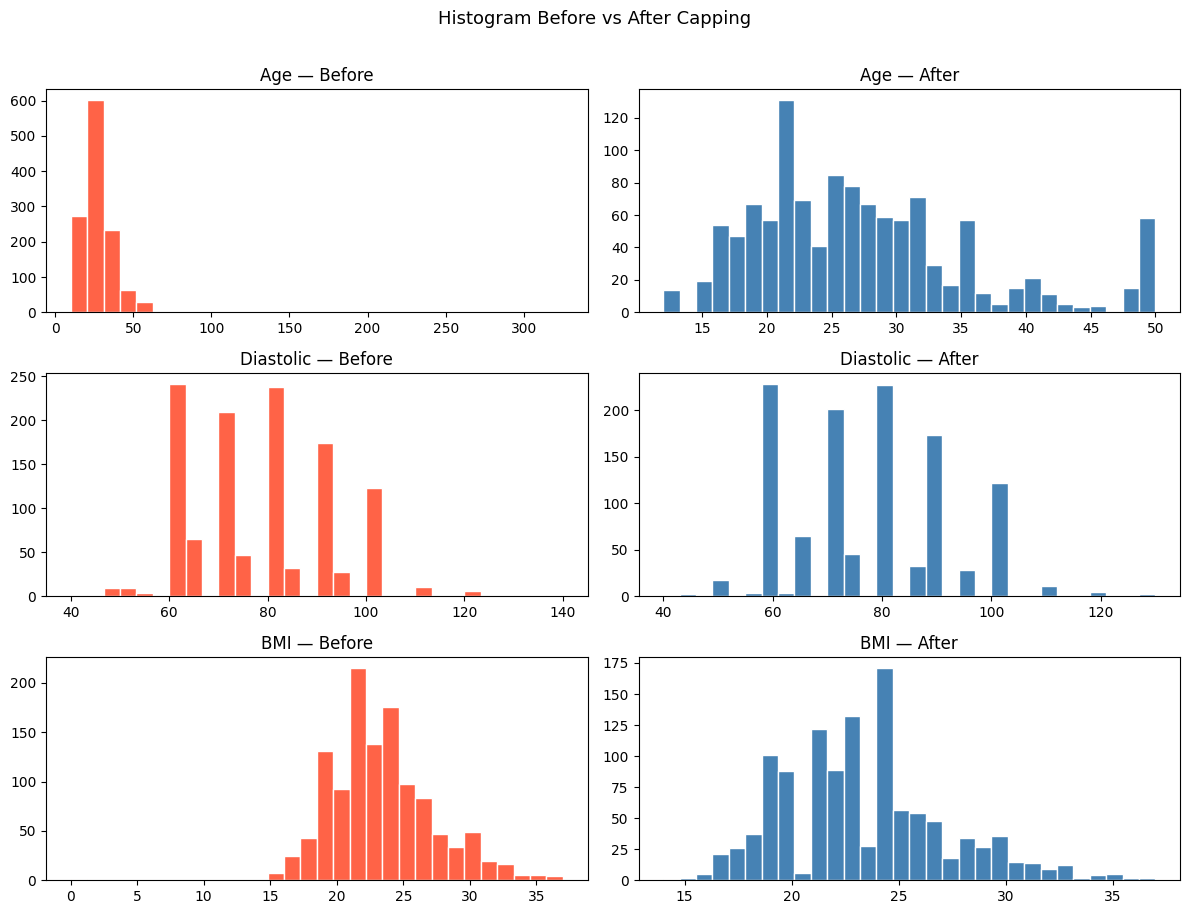

In [22]:
fig, axes = plt.subplots(len(capped_columns), 2, figsize=(12, len(capped_columns) * 3))

for i, col in enumerate(capped_columns):
    axes[i][0].hist(df[col].dropna(), bins=30, color="tomato", edgecolor="white")
    axes[i][0].set_title(f"{col} — Before")

    axes[i][1].hist(df_clean[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i][1].set_title(f"{col} — After")

plt.suptitle("Histogram Before vs After Capping", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17248\39799461.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i],


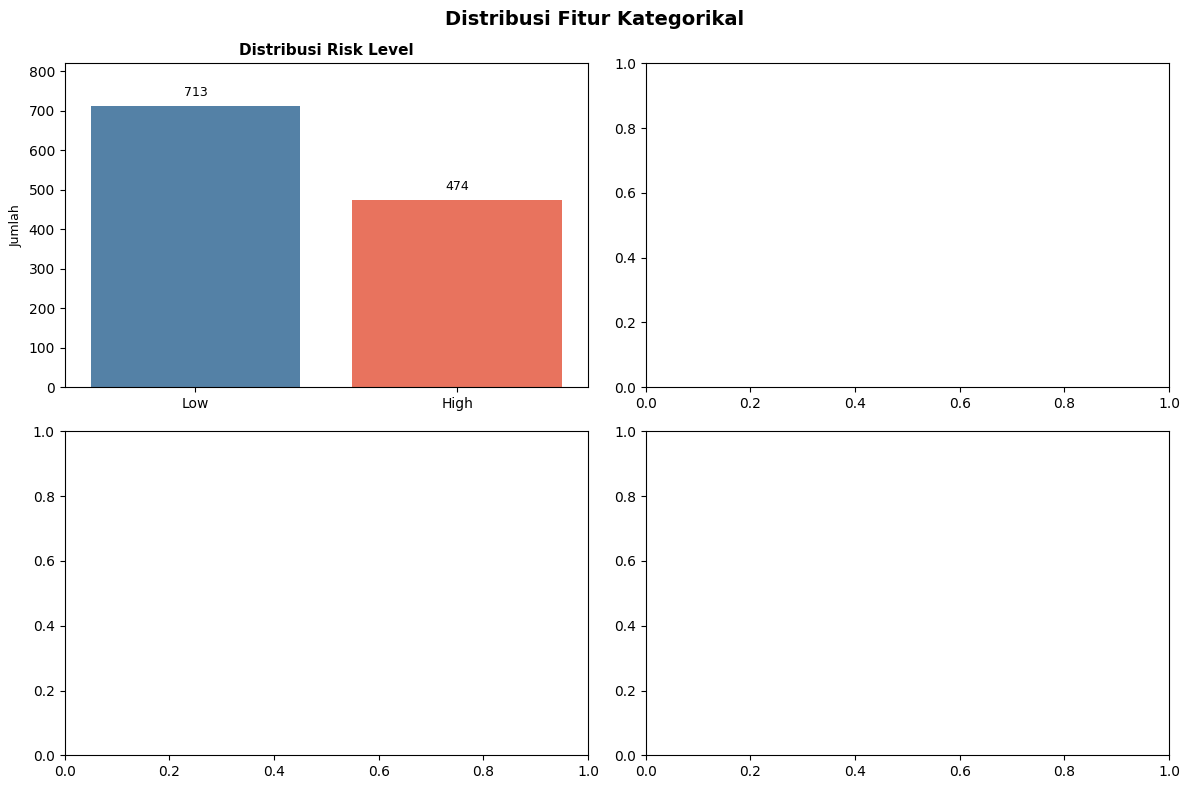

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ['steelblue', 'tomato']

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i],
                  order=order, palette=colors)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah', fontsize=9)

    current_max = df[col].value_counts().values[0]
    axes[i].set_ylim(0, current_max * 1.15)

    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9,
                        xytext=(0, 5), textcoords='offset points')

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

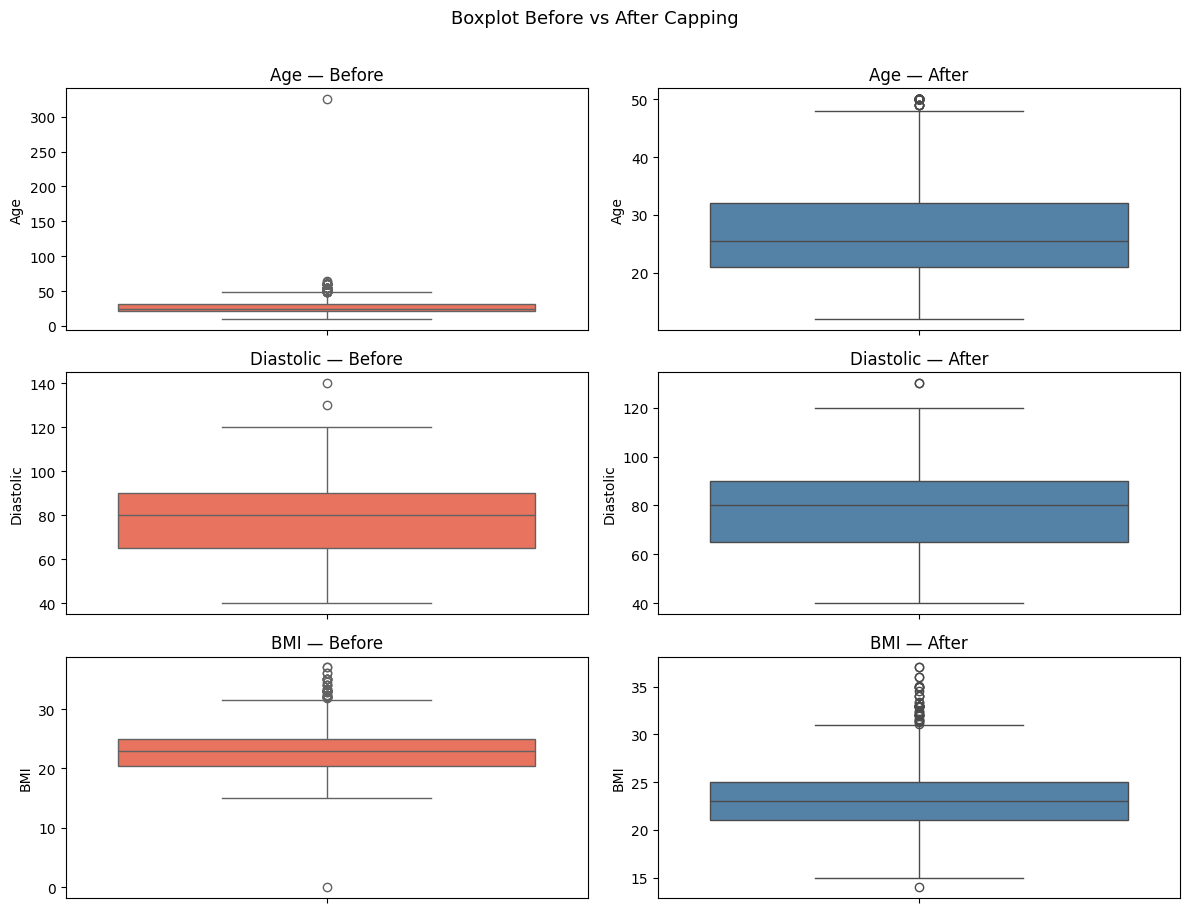

In [24]:
fig, axes = plt.subplots(len(capped_columns), 2, figsize=(12, len(capped_columns) * 3))

for i, col in enumerate(capped_columns):
    sns.boxplot(y=df[col], ax=axes[i][0], color="tomato")
    axes[i][0].set_title(f"{col} — Before")

    sns.boxplot(y=df_clean[col], ax=axes[i][1], color="steelblue")
    axes[i][1].set_title(f"{col} — After")

plt.suptitle("Boxplot Before vs After Capping", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Ringkasan Cleaning

| Tahap | Jumlah Baris |
|---|---|
| Sebelum Cleaning | 1.205 |
| Setelah Drop Duplikat | 1.187 |
| Setelah Drop Target NaN | 1.169 |
| Setelah Imputation (Median) | 1.169 |
| Setelah Domain-Based Capping | 1.169 |
| Setelah Drop Duplikat Post-Capping | 1.168 |

Imputation dilakukan menggunakan median untuk kolom numerik (Systolic BP,
Diastolic, BS, BMI, Heart Rate) dan modus untuk kolom kategorikal.
Capping diterapkan pada Age (34 nilai), Diastolic (1 nilai), dan BMI
(1 nilai) menggunakan batas klinis WHO/ACOG. Satu duplikat sintetik
yang muncul akibat proses capping dieliminasi pada tahap akhir.

#Pre Visualization and Analysis

###Memisahkan Kolom Numerik dan Kategorikal

In [25]:
num_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']
cat_cols = ['Previous Complications', 'Preexisting Diabetes',
            'Gestational Diabetes', 'Mental Health']

print("Kolom Numerik:", num_cols)
print("Kolom Kategorikal:", cat_cols)

Kolom Numerik: ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']
Kolom Kategorikal: ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health']


#EDA (Exploratory Data Analysis)

###Univariate Analysis


#####Distribusi Fitur Numerik

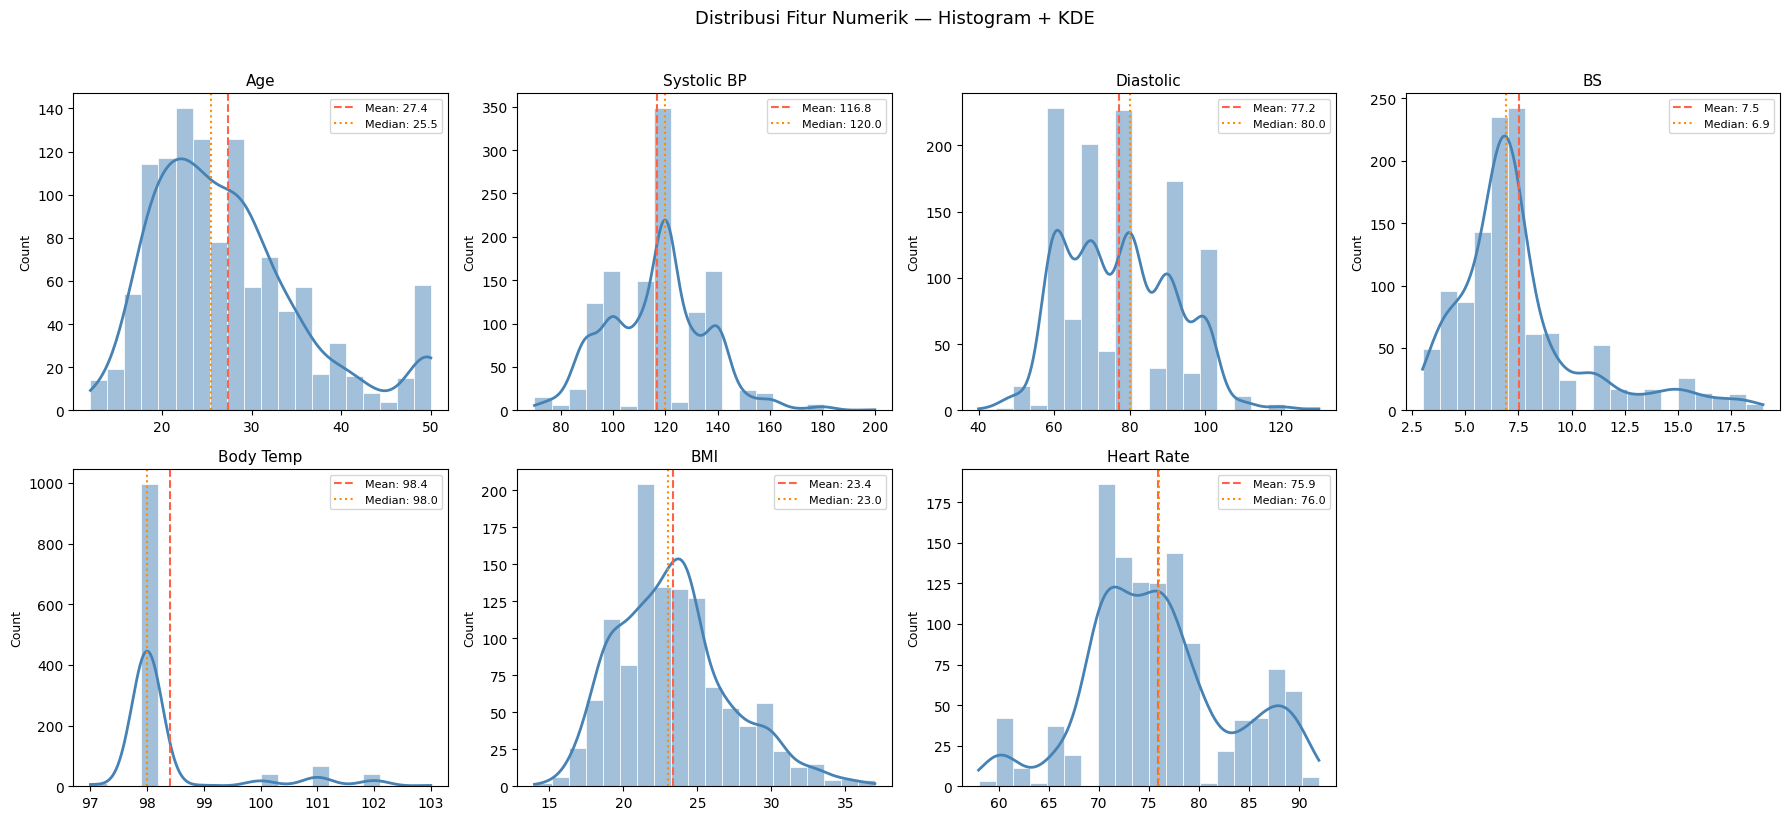

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    sns.histplot(data=df_clean, x=col, bins=20,
                 color="steelblue", edgecolor="white",
                 linewidth=0.5, kde=True,
                 line_kws={"color": "navy", "linewidth": 2},
                 ax=ax)

    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()

    ax.axvline(mean_val, color="tomato", linestyle="--",
               linewidth=1.5, label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color="darkorange", linestyle=":",
               linewidth=1.5, label=f"Median: {median_val:.1f}")

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8)

# hide unused subplot if num_cols < 8
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik — Histogram + KDE", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

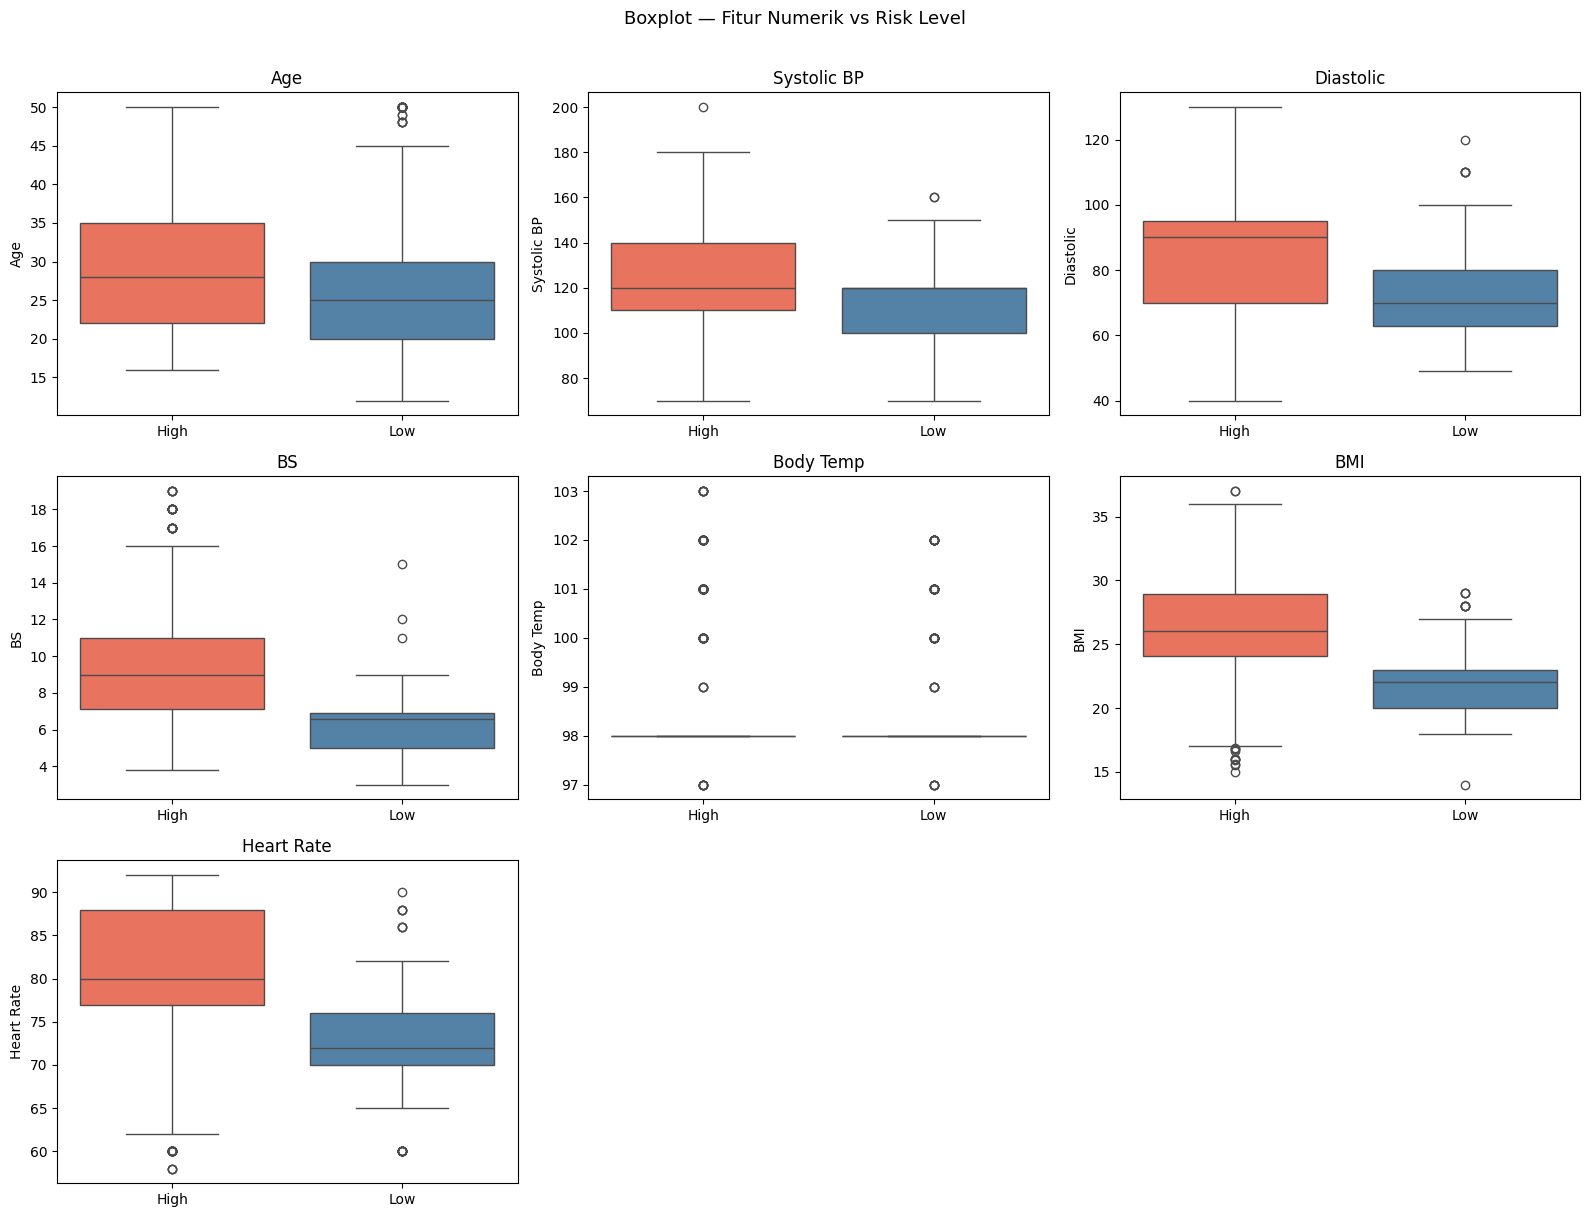

In [27]:
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x="Risk Level", y=col, ax=axes[i],
                order=["High", "Low"],
                hue = "Risk Level",
                palette={"High": "tomato", "Low": "steelblue"})
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot — Fitur Numerik vs Risk Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

##### Distribusi Fitur Kategorikal

C:\Users\USER\AppData\Local\Temp\ipykernel_17248\1531882078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i],
C:\Users\USER\AppData\Local\Temp\ipykernel_17248\1531882078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i],
C:\Users\USER\AppData\Local\Temp\ipykernel_17248\1531882078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i],
C:\Users\USER\AppData\Local\Temp\ipykernel_17248\1531882078.py:8: FutureWarning: 

Passing `palette` wi

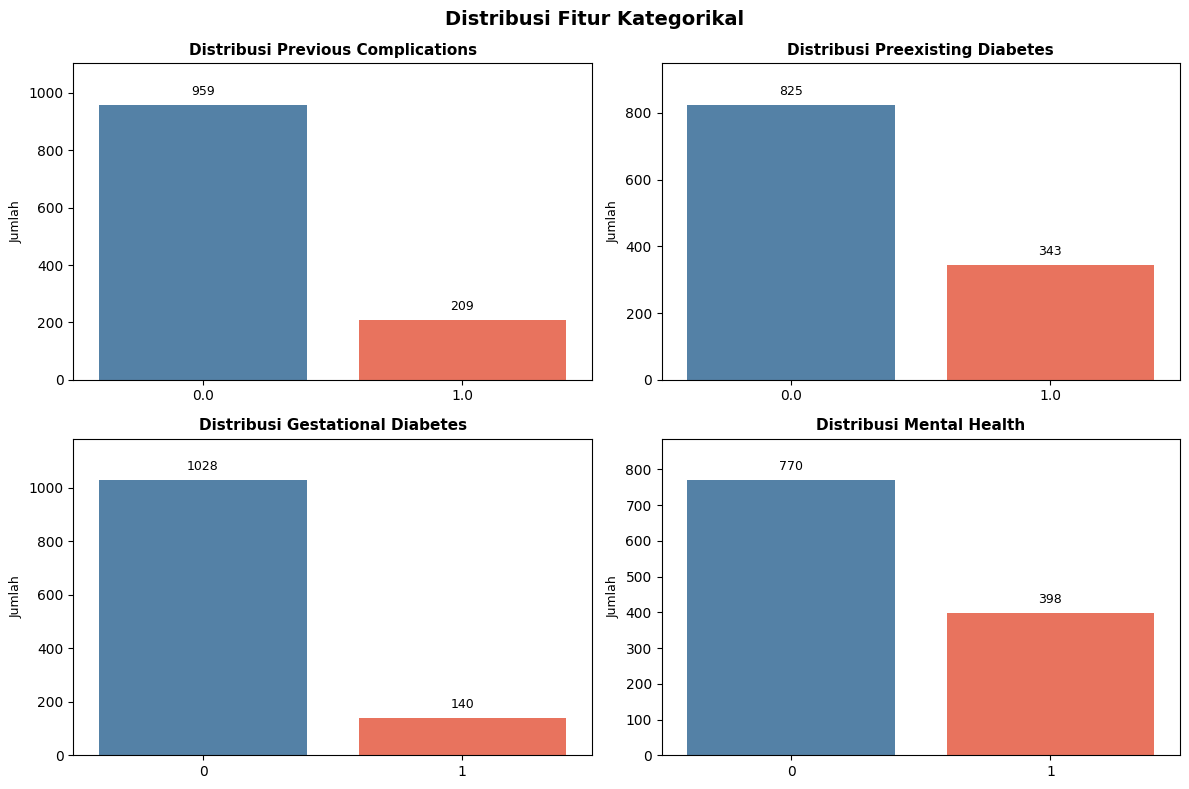

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ['steelblue', 'tomato']

for i, col in enumerate(cat_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, ax=axes[i],
                  order=order, palette=colors)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah', fontsize=9)

    current_max = df_clean[col].value_counts().values[0]
    axes[i].set_ylim(0, current_max * 1.15)

    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9,
                        xytext=(0, 5), textcoords='offset points')

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Distribusi Target

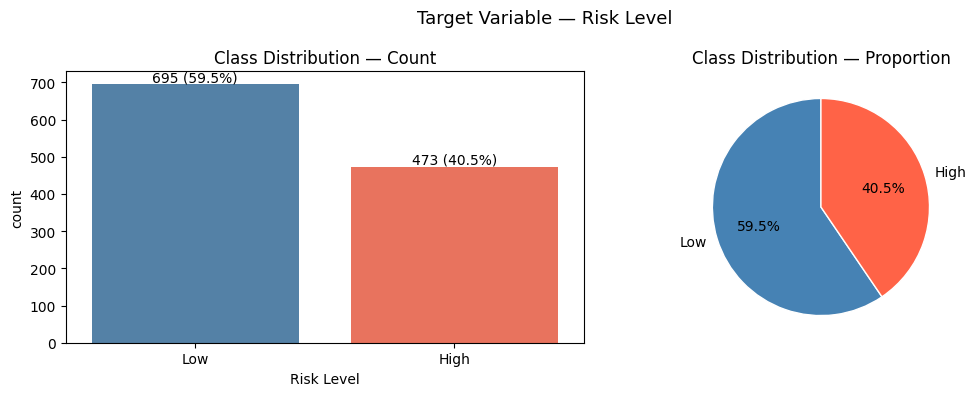

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Countplot
sns.countplot(data=df_clean, x="Risk Level", ax=axes[0],
              order=["Low","High"],
              hue="Risk Level",
              palette={"High": "tomato", "Low": "steelblue"})
axes[0].set_title("Class Distribution — Count")
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df_clean)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

# Pie chart
target_counts = df_clean["Risk Level"].value_counts()
axes[1].pie(target_counts, labels=target_counts.index,
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Distribution — Proportion")

plt.suptitle("Target Variable — Risk Level", fontsize=13)
plt.tight_layout()
plt.show()

#####Chi-Square Test

In [30]:
from scipy.stats import chi2_contingency

cat_cols = ["Previous Complications", "Preexisting Diabetes",
            "Gestational Diabetes", "Mental Health"]

chi2_results = []

for col in cat_cols:
    ct = pd.crosstab(df_clean[col], df_clean["Risk Level"])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        "Feature"       : col,
        "Chi-Square"    : round(chi2, 4),
        "Degrees of Freedom": dof,
        "p-value"       : f"{p:.3e}",
        "Result"        : "Significant" if p < 0.05 else "Not Significant"
    })

chi2_df = pd.DataFrame(chi2_results).set_index("Feature")
display(chi2_df)

,Chi-Square,Degrees of Freedom,p-value,Result
Feature,,,,
Previous Complications,335.9437,1,4.878e-75,Significant
Preexisting Diabetes,540.2621,1,1.654e-119,Significant
Gestational Diabetes,230.9258,1,3.745e-52,Significant
Mental Health,469.6761,1,3.769e-104,Significant


### Bivariate Analysis

#####Fitur Numerik vs Risk Level

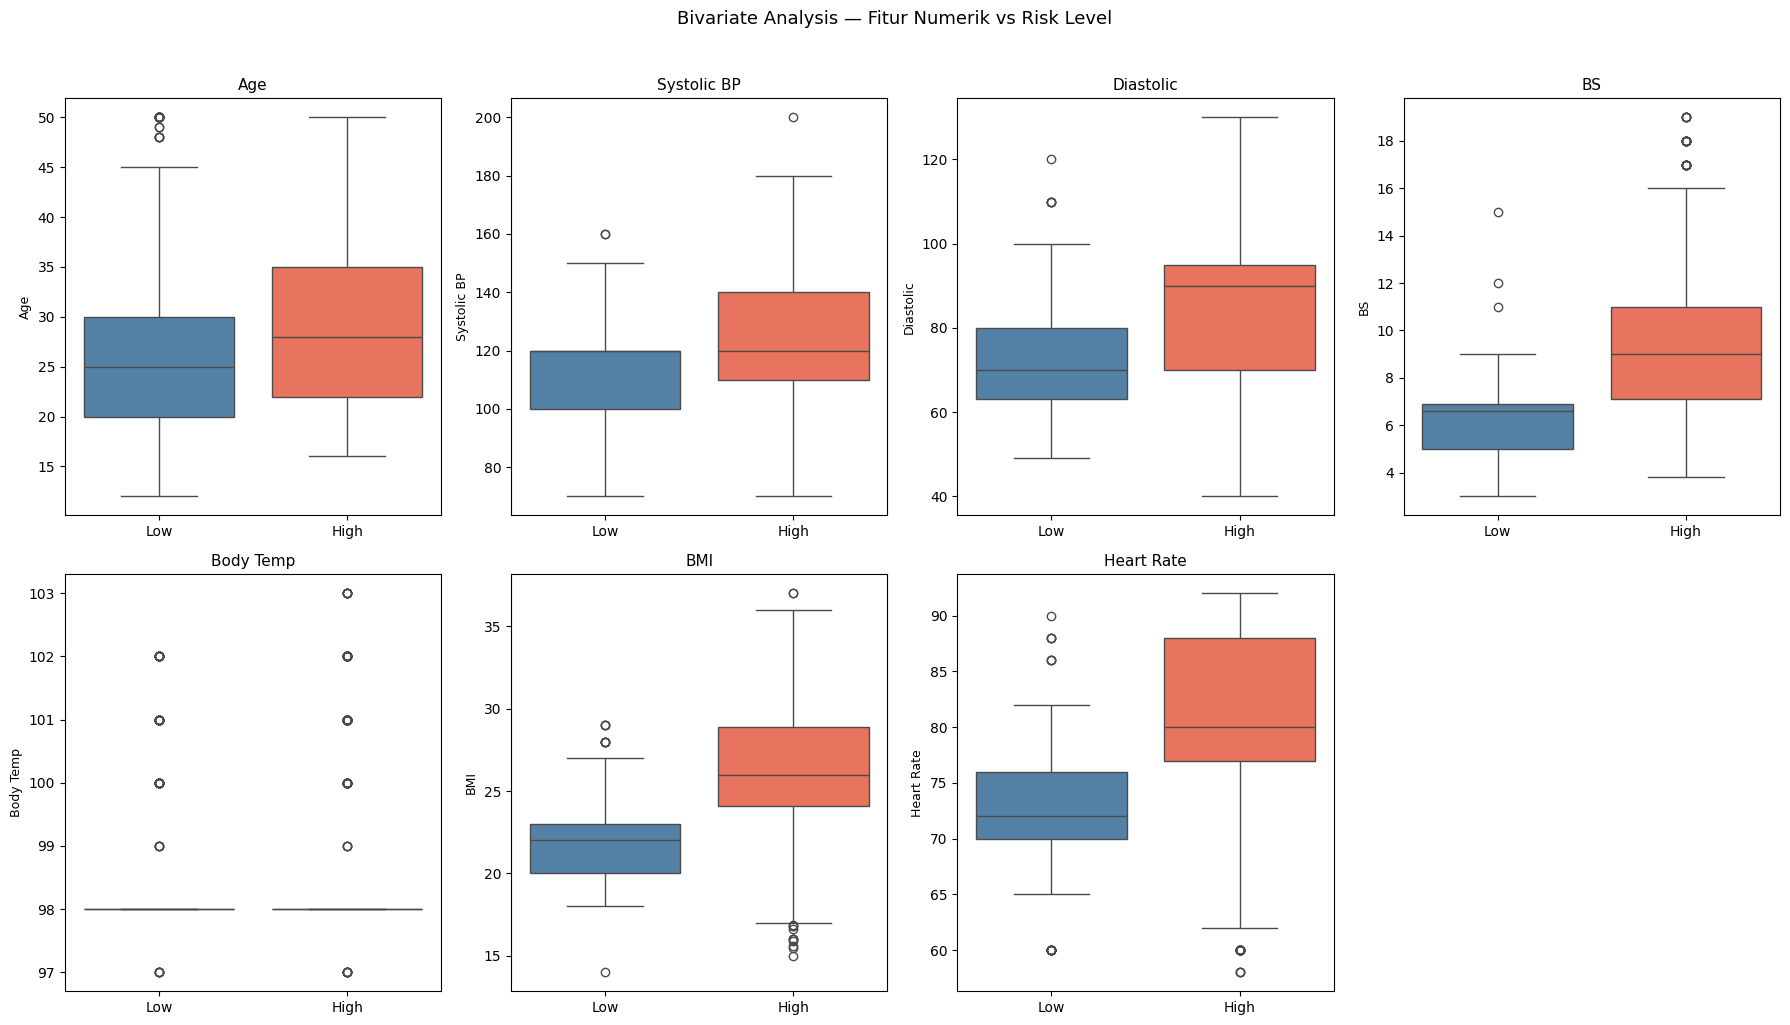

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x="Risk Level", y=col,
                hue="Risk Level", order=["Low", "High"],
                palette={"Low": "steelblue", "High": "tomato"},
                legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col, fontsize=9)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate Analysis — Fitur Numerik vs Risk Level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#####Fitur Kategorikal vs Risk Level

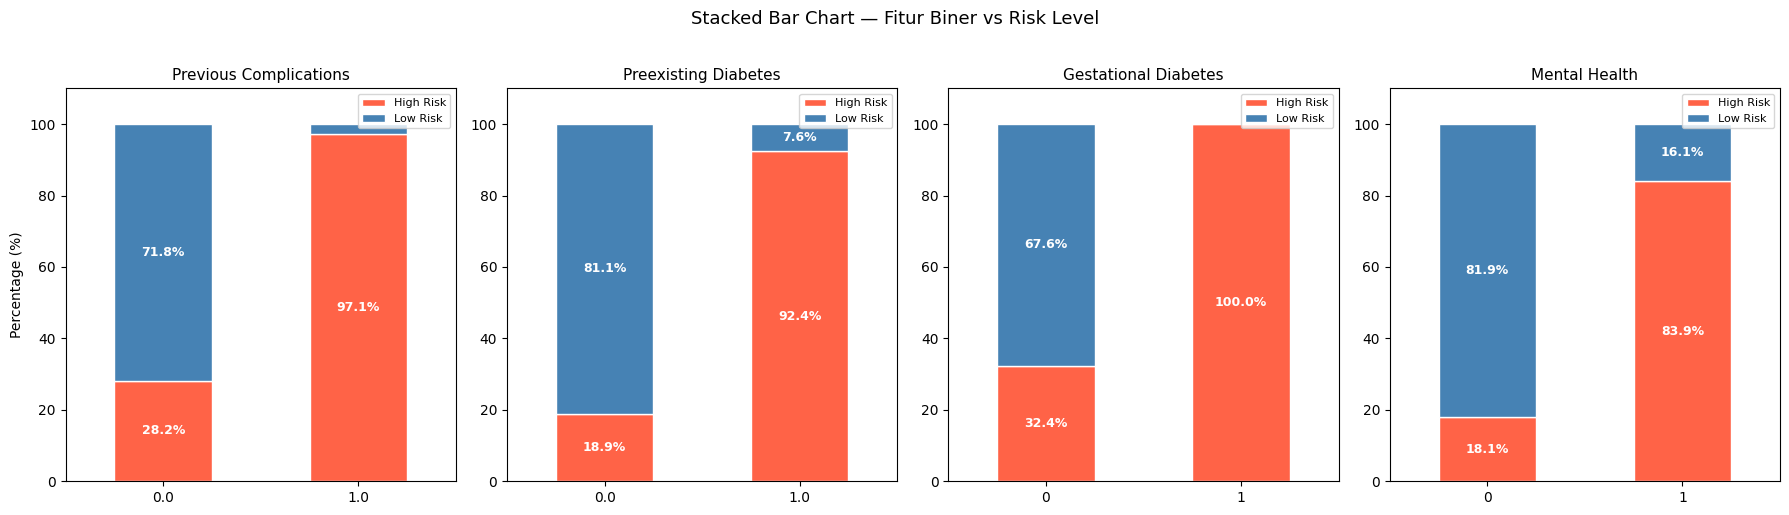

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean["Risk Level"], normalize="index") * 100

    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["tomato", "steelblue"], edgecolor="white", width=0.5)

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)" if i == 0 else "")
    axes[i].set_ylim(0, 110)
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(["High Risk", "Low Risk"], fontsize=8, loc="upper right")

    # annotate tiap segment
    for bar in axes[i].patches:
        height = bar.get_height()
        if height > 3:  # skip label kalau segment terlalu kecil
            axes[i].annotate(
                f"{height:.1f}%",
                (bar.get_x() + bar.get_width() / 2,
                 bar.get_y() + height / 2),
                ha="center", va="center",
                fontsize=9, color="white", fontweight="bold"
            )

plt.suptitle("Stacked Bar Chart — Fitur Biner vs Risk Level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Multivariate Analysis

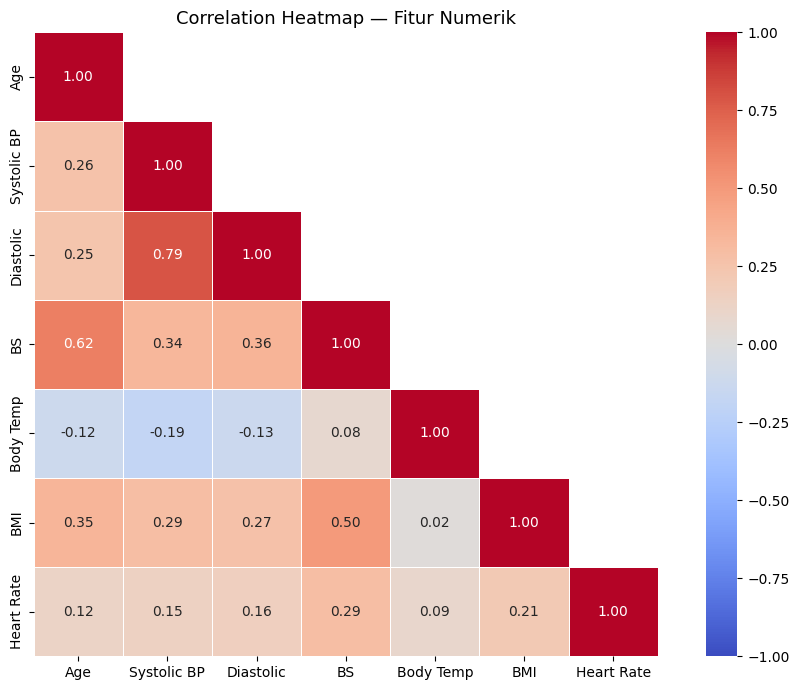

In [33]:
plt.figure(figsize=(10, 7))
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1 biarkan diagonal tampil

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Fitur Numerik", fontsize=13)
plt.tight_layout()
plt.show()

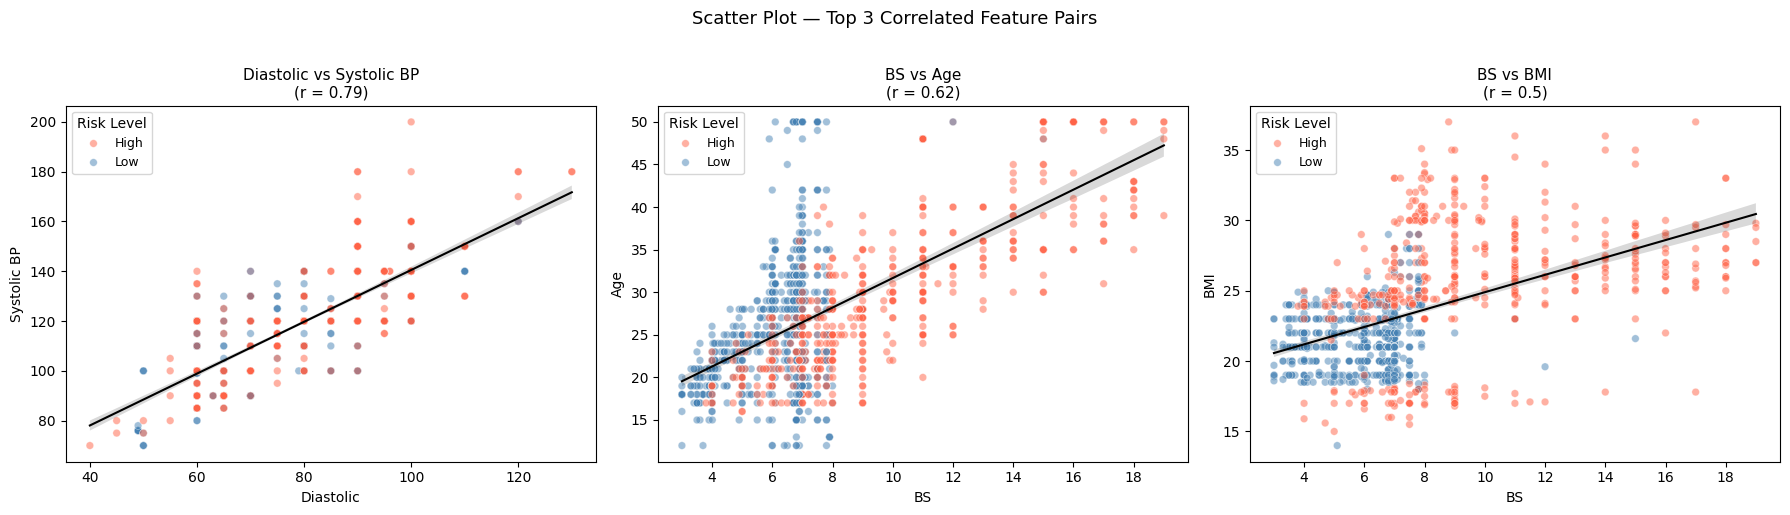

In [34]:
top_pairs = [
    ("Diastolic", "Systolic BP", 0.79),
    ("BS", "Age", 0.62),
    ("BS", "BMI", 0.50),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x_col, y_col, corr) in enumerate(top_pairs):
    sns.scatterplot(data=df_clean, x=x_col, y=y_col,
                    hue="Risk Level",
                    palette={"Low": "steelblue", "High": "tomato"},
                    alpha=0.5, s=30, ax=axes[i])

    # regression line
    sns.regplot(data=df_clean, x=x_col, y=y_col,
                scatter=False, color="black", line_kws={"linewidth": 1.5},
                ax=axes[i])

    axes[i].set_title(f"{x_col} vs {y_col}\n(r = {corr})", fontsize=11)
    axes[i].set_xlabel(x_col, fontsize=10)
    axes[i].set_ylabel(y_col, fontsize=10)
    axes[i].legend(title="Risk Level", fontsize=9)

plt.suptitle("Scatter Plot — Top 3 Correlated Feature Pairs", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
df_clean.to_csv('../data/processed/maternal_health_cleaned.csv', index=False)

##### Insight yang bisa diambil

- Distribusi BS dan Age condong ke kanan (positively skewed)
- Body Temp hampir semua nilainya sama — variasinya sangat kecil
- Dataset memiliki mild imbalance: High Risk 40.4% vs Low Risk 59.6%
- Mayoritas pasien tidak memiliki kondisi medis biner (Previous Complications,
  Preexisting Diabetes, Gestational Diabetes, Mental Health)